<a href="https://colab.research.google.com/github/Natnael9/Book-Store/blob/main/Omnicampus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)


In [3]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/Final Assignment


/content/drive/MyDrive/Final Assignment


In [5]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/Final Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/Final Assignment/telecom/Record.csv


In [6]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [7]:
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


In [36]:
# Cell was removed as Customer_ID is no longer in df at this point, and customer_ids_test is correctly derived from 'client' in cell 4abe3bc8.

In [8]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


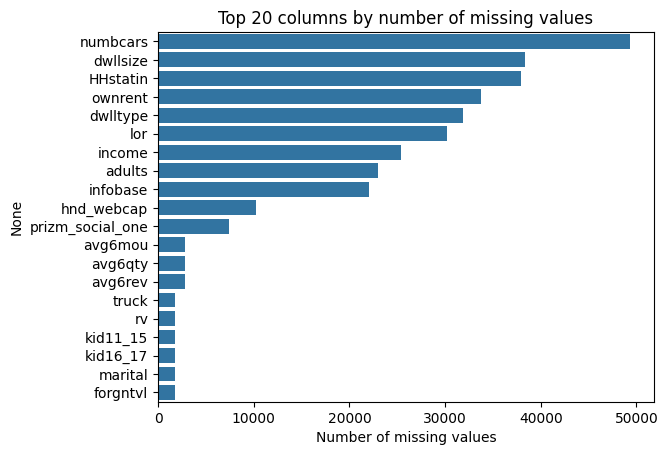

In [9]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

## Analyzing the Balance of Usage (mou_Mean)

Counts of usage levels:
usage_level
Medium Usage    44782
High Usage      37217
Low Usage       17644
Name: count, dtype: int64

Proportions of usage levels:
usage_level
Medium Usage    0.449424
High Usage      0.373503
Low Usage       0.177072
Name: proportion, dtype: float64


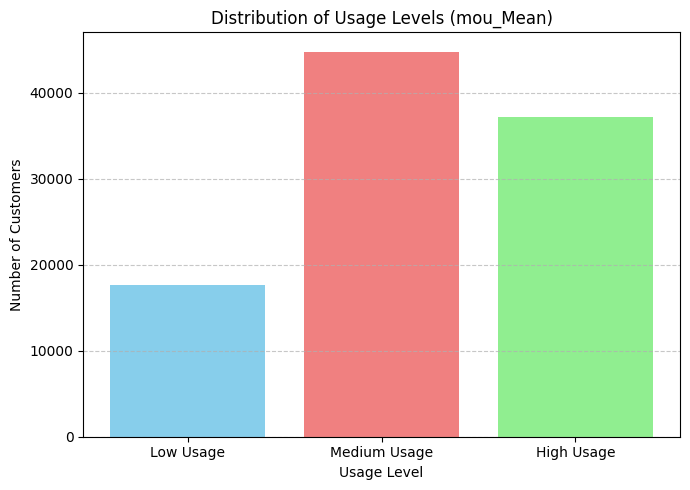

In [14]:
# Define bins for mou_Mean to categorize usage
bins = [0, 100, 500, df['mou_Mean'].max() + 1] # +1 to ensure max value is included
labels = ['Low Usage', 'Medium Usage', 'High Usage']

# Create a new categorical column for usage levels
df['usage_level'] = pd.cut(df['mou_Mean'], bins=bins, labels=labels, right=False, include_lowest=True)

# Counts and proportions for 'usage_level'
print("Counts of usage levels:")
print(df['usage_level'].value_counts())
print("\nProportions of usage levels:")
print(df['usage_level'].value_counts(normalize=True))

# Bar chart for 'usage_level'
counts_usage = df['usage_level'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(counts_usage.index, counts_usage.values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Distribution of Usage Levels (mou_Mean)')
plt.xlabel('Usage Level')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---

### Feature Comparison: Equipment Age (`eqpdays`)

/tmp/ipykernel_1309/2948803727.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='usage_level', y='eqpdays', data=df, palette='viridis')


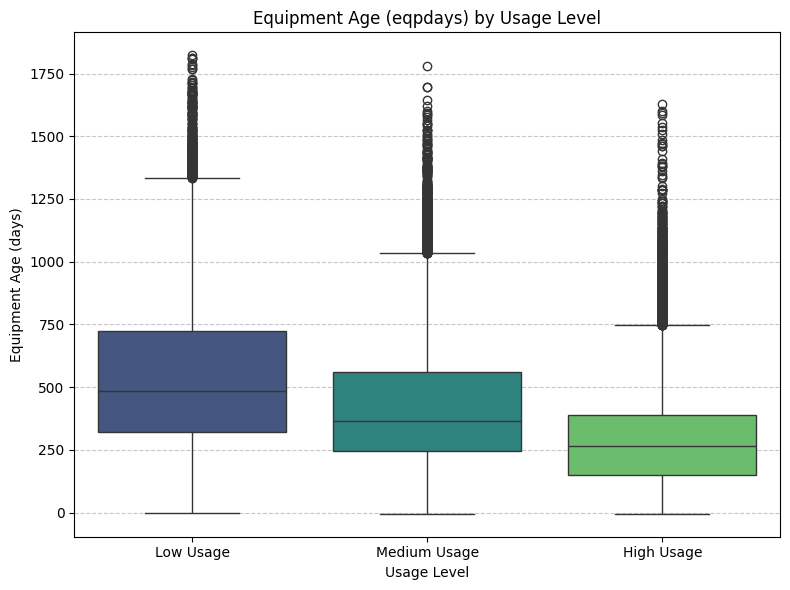

Mean Equipment Age by Usage Level:


/tmp/ipykernel_1309/2948803727.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('usage_level')['eqpdays'].mean())


,eqpdays
usage_level,
Low Usage,539.085020
Medium Usage,412.710531
High Usage,295.024236


In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='usage_level', y='eqpdays', data=df, palette='viridis')
plt.title('Equipment Age (eqpdays) by Usage Level')
plt.xlabel('Usage Level')
plt.ylabel('Equipment Age (days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Mean Equipment Age by Usage Level:")
display(df.groupby('usage_level')['eqpdays'].mean())

**Interpretation and Business Lever for `eqpdays`:**

If the 'Low Usage' group shows a significantly higher mean or median `eqpdays` (older equipment), it suggests that customers with older phones might be using their service less. This presents a clear intervention opportunity: **targeted upgrade offers**. Offering incentives for new handsets to 'Low Usage' customers with old equipment could stimulate usage and potentially reduce churn, moving them into 'Medium' or 'High Usage' categories.

---

### Feature Comparison: Trend in Usage (`change_mou`)

/tmp/ipykernel_1309/1930330061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='usage_level', y='change_mou', data=df, palette='magma')


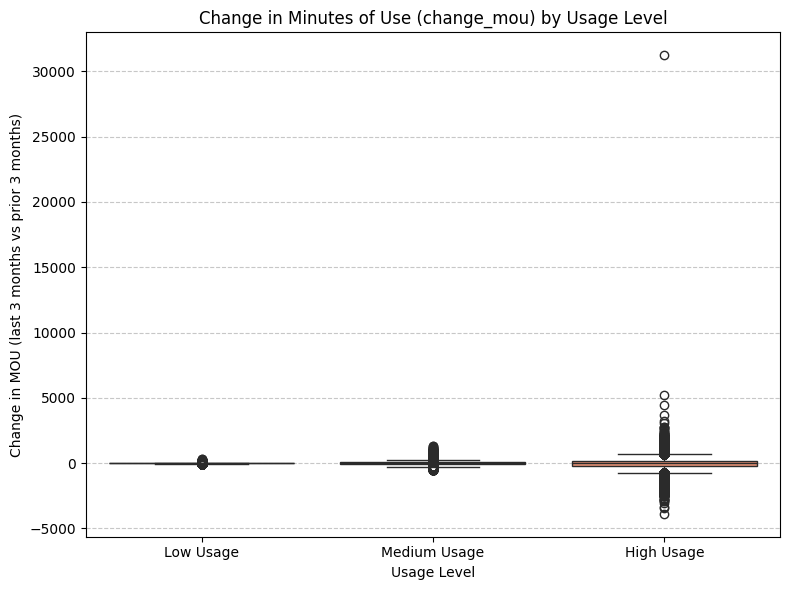

Mean Change in Minutes of Use by Usage Level:


/tmp/ipykernel_1309/1930330061.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('usage_level')['change_mou'].mean())


,change_mou
usage_level,
Low Usage,-2.768569
Medium Usage,-10.782387
High Usage,-22.972013


In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='usage_level', y='change_mou', data=df, palette='magma')
plt.title('Change in Minutes of Use (change_mou) by Usage Level')
plt.xlabel('Usage Level')
plt.ylabel('Change in MOU (last 3 months vs prior 3 months)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Mean Change in Minutes of Use by Usage Level:")
display(df.groupby('usage_level')['change_mou'].mean())

**Interpretation and Business Lever for `change_mou`:**

If 'Low Usage' customers exhibit a more negative `change_mou` (indicating a significant decrease in their usage trend), it confirms they are actively disengaging. This is a strong signal for **proactive engagement campaigns**. The business could intervene with personalized offers (e.g., bonus data, discounted plans, or new service features) designed to re-engage these customers and reverse their declining usage trend before they churn.

---

### Feature Comparison: Customer Care Volume (`custcare_Mean`)

/tmp/ipykernel_1309/3748959481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='usage_level', y='custcare_Mean', data=df, palette='plasma')


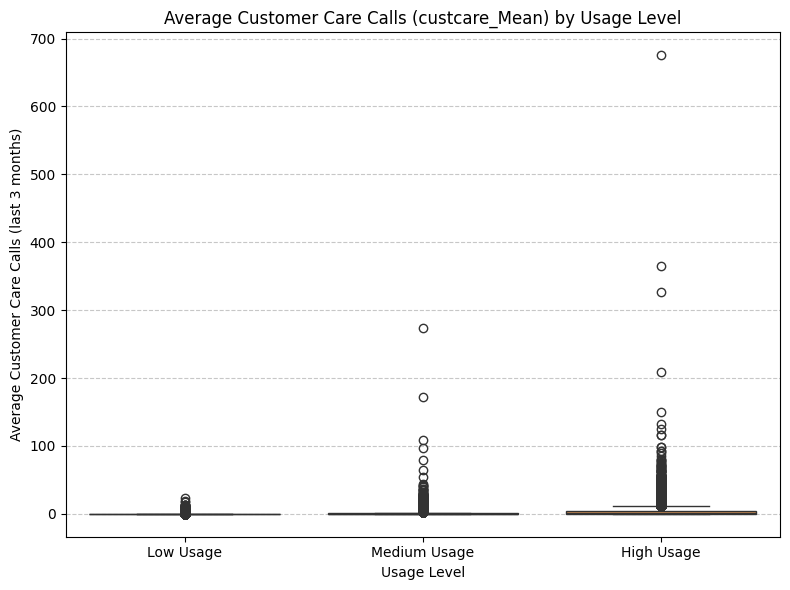

Mean Customer Care Calls by Usage Level:


/tmp/ipykernel_1309/3748959481.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('usage_level')['custcare_Mean'].mean())


,custcare_Mean
usage_level,
Low Usage,0.173241
Medium Usage,0.908386
High Usage,3.632036


In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='usage_level', y='custcare_Mean', data=df, palette='plasma')
plt.title('Average Customer Care Calls (custcare_Mean) by Usage Level')
plt.xlabel('Usage Level')
plt.ylabel('Average Customer Care Calls (last 3 months)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Mean Customer Care Calls by Usage Level:")
display(df.groupby('usage_level')['custcare_Mean'].mean())

**Interpretation and Business Lever for `custcare_Mean`:**

If 'Low Usage' customers have a higher mean `custcare_Mean` (more interactions with customer care), it could indicate underlying technical issues, service dissatisfaction, or frustration with their current plan. The intervenable lever here is **proactive customer support and problem resolution**. By identifying these 'Low Usage' customers with high customer care interactions, the business can reach out to them to resolve issues, offer tailored support, or clarify service details, potentially alleviating frustrations and encouraging higher usage.

## Pairwise EDA with `seaborn.pairplot`, Grouped Statistics, and Correlation Analysis

This section provides a detailed exploratory data analysis of key features (`rev_Mean`, `mou_Mean`, `totmrc_Mean`, `eqpdays`, `change_mou`) by `usage_level`.

<Figure size 1500x1500 with 0 Axes>

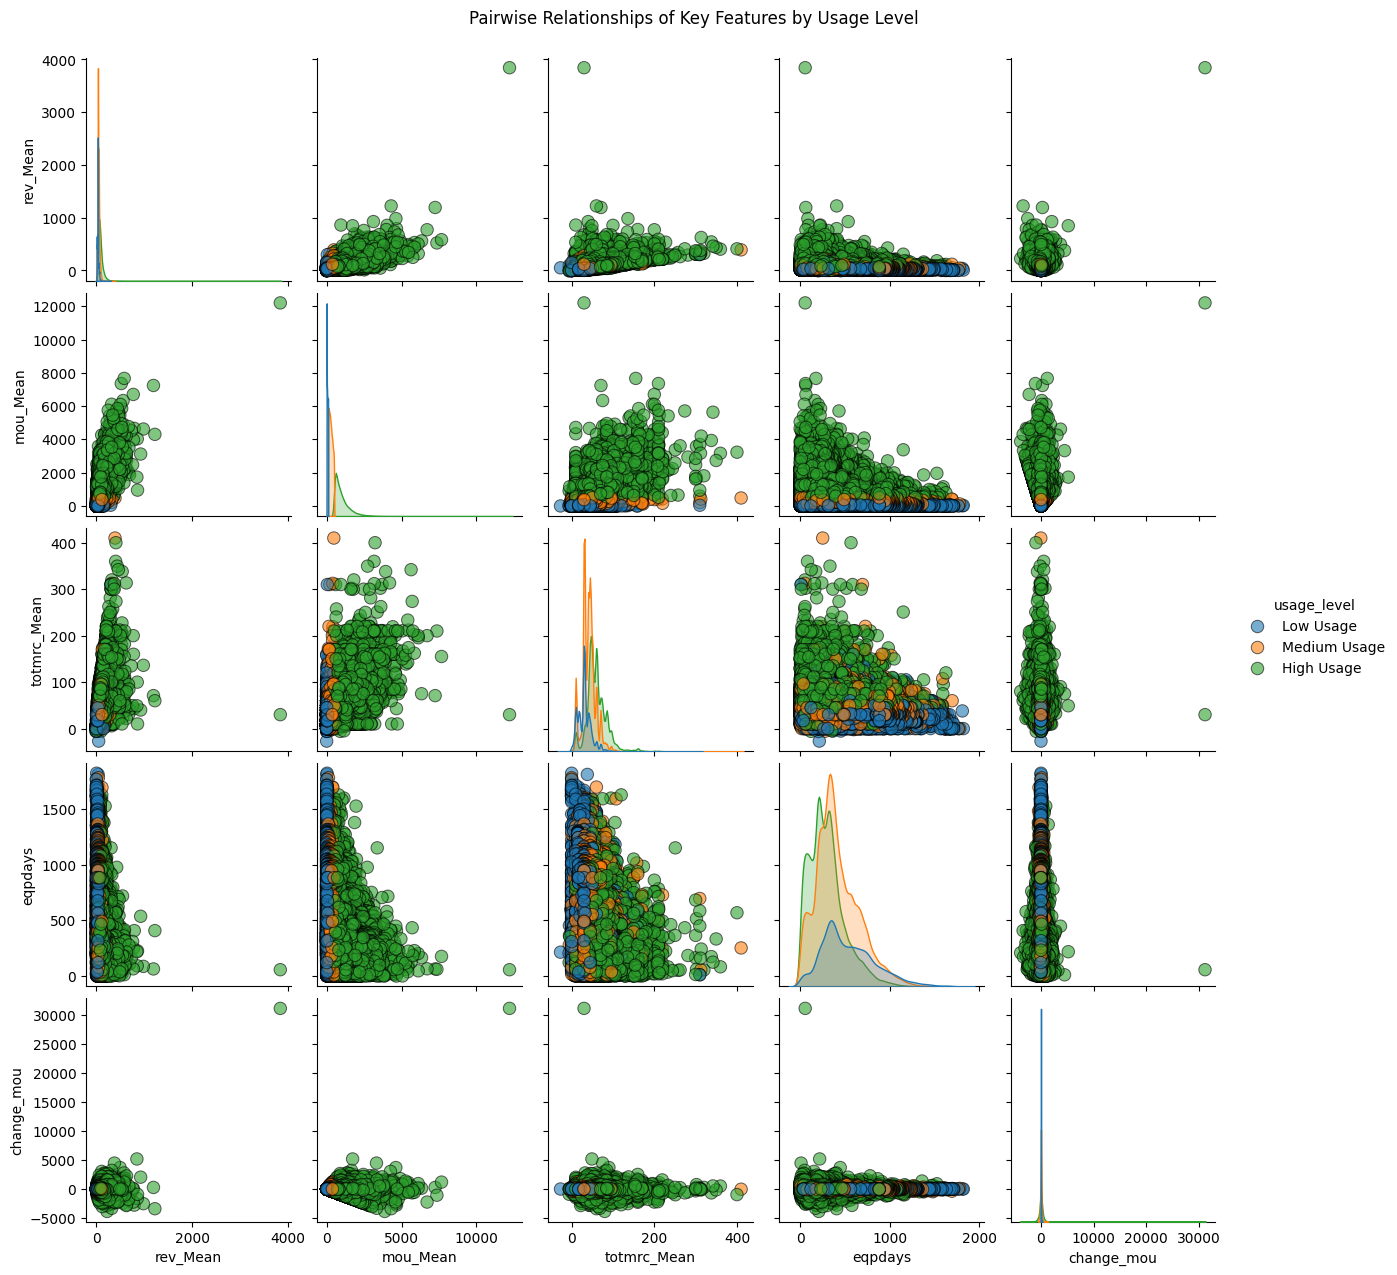

In [19]:
# Define the features for pairwise EDA
features_for_pairplot = ['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'eqpdays', 'change_mou', 'usage_level']

# Create the pairplot
plt.figure(figsize=(15, 15))
sns.pairplot(
    df[features_for_pairplot].dropna(), # Drop NaNs for cleaner plot, if any
    hue='usage_level',
    palette='tab10',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'k'}
)
plt.suptitle('Pairwise Relationships of Key Features by Usage Level', y=1.02) # Adjust suptitle position
plt.show()

### Interpretation of the Pairplot

The `pairplot` provides a visual way to understand the relationships between different features and how these relationships vary across `usage_level` categories:

*   **Off-Diagonal Scatter Plots (Joint Distributions):** These plots show the correlation and spread between each pair of features. Observe if the clusters for 'Low Usage', 'Medium Usage', and 'High Usage' are distinct or overlapping. Clear separation indicates that the features are good discriminators for usage levels. For example, a strong linear correlation between two features (points forming a line) suggests redundancy.

*   **Diagonal KDE Plots (Marginal Distributions):** These plots show the probability density function for each feature, colored by `usage_level`. Look for distinct peaks and troughs for each usage level. If the KDEs for different `usage_level` categories are well-separated, it suggests that the feature has a strong influence on differentiating usage levels. If they largely overlap, the feature might not be as strong a differentiator on its own.

### Grouped Summary Statistics: Mean and Median

To quantify the differences observed in the visualizations, let's calculate the mean and median for each of these features, grouped by `usage_level`.

In [20]:
# Features to analyze
analysis_features = ['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'eqpdays', 'change_mou']

print("Mean for each feature grouped by Usage Level:")
display(df.groupby('usage_level')[analysis_features].mean())

print("\nMedian for each feature grouped by Usage Level:")
display(df.groupby('usage_level')[analysis_features].median())

Mean for each feature grouped by Usage Level:


/tmp/ipykernel_1309/1201416422.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('usage_level')[analysis_features].mean())


,rev_Mean,mou_Mean,totmrc_Mean,eqpdays,change_mou
usage_level,,,,,
Low Usage,29.897137,42.794725,30.253559,539.085020,-2.768569
Medium Usage,45.125622,277.490857,40.986829,412.710531,-10.782387
High Usage,88.742100,1020.796602,59.976936,295.024236,-22.972013



Median for each feature grouped by Usage Level:


/tmp/ipykernel_1309/1201416422.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('usage_level')[analysis_features].median())


,rev_Mean,mou_Mean,totmrc_Mean,eqpdays,change_mou
usage_level,,,,,
Low Usage,30.17750,40.5,29.990,484.0,-2.00
Medium Usage,40.90375,267.0,39.990,366.0,-11.50
High Usage,75.76250,856.5,59.425,267.0,-13.75


### Interpretation: Distinct Numerical Shift and Business Levers

By examining the mean and median values grouped by `usage_level`, we can quantify the differences:

*   **`rev_Mean` (Average Monthly Revenue):** This shows the most direct 'revenue gap' between usage groups. A significant difference here provides strong evidence for a business proposal focusing on increasing revenue from 'Low Usage' and 'Medium Usage' customers.
    *   **Business Lever:** Understand what drives higher revenue in 'High Usage' groups (e.g., more services, higher-tier plans) and tailor promotions or upsell strategies for lower usage groups.

*   **`mou_Mean` (Average Minutes of Use):** This is the direct driver of `usage_level`. The distinct numerical shifts here confirm the effectiveness of the categorization.
    *   **Business Lever:** Strategies to increase `mou_Mean` in lower usage groups could involve value-added services, family plans, or incentives for longer calls/data usage.

*   **`totmrc_Mean` (Average Total Monthly Recurring Charges):** This is highly related to `rev_Mean` and often shows a similar trend. If the difference is substantial, it supports proposals around optimizing plan structures.
    *   **Business Lever:** Adjust pricing tiers or introduce more flexible plans that encourage users to move to higher usage (and thus higher recurring charge) brackets.

*   **`eqpdays` (Equipment Age):** As previously observed, 'Low Usage' customers tend to have older equipment. The numerical difference in mean/median `eqpdays` provides concrete data for targeted upgrade campaigns.
    *   **Business Lever:** Offer aggressive discounts or easy upgrade paths for older equipment in the 'Low Usage' segment to encourage renewed engagement.

*   **`change_mou` (Change in Minutes of Use):** This metric quantifies the trend. If 'Low Usage' groups have a more negative `change_mou`, it highlights a critical segment at risk of churn.
    *   **Business Lever:** Proactive outreach, personalized offers, or customer retention campaigns targeting customers with declining usage trends.

These numerical differences provide a strong **evidence base** for a business proposal. For instance, quantifying the average revenue difference between 'Low' and 'High' usage customers directly illustrates the potential financial gain from moving customers up the usage ladder. Similarly, knowing the average equipment age for 'Low Usage' customers justifies the investment in targeted upgrade promotions.

### Correlation Matrix

Let's generate a correlation matrix to quantitatively assess the linear relationships between these features. A heatmap will make these relationships easy to visualize.

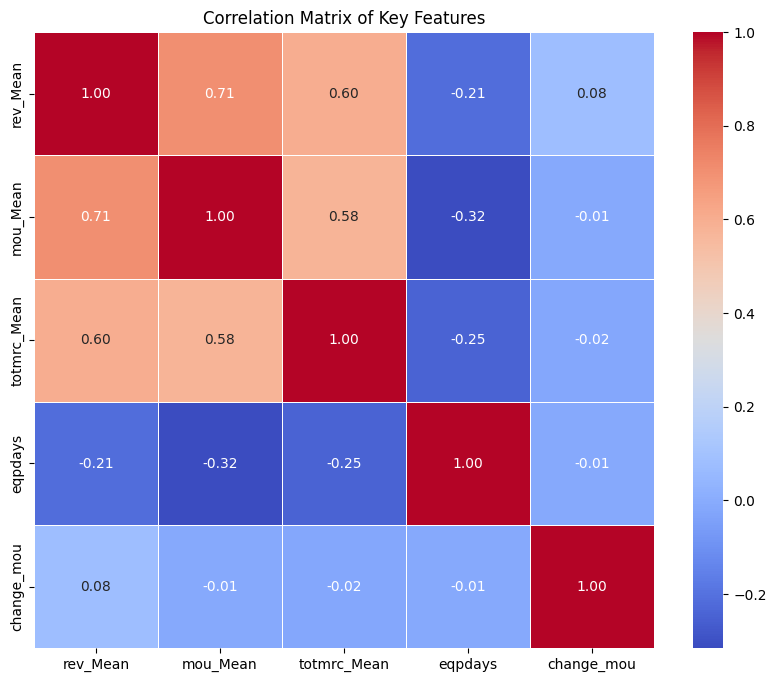

In [21]:
# Calculate the correlation matrix for the analysis features
correlation_matrix = df[analysis_features].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f", # Format annotation to two decimal places
    linewidths=.5 # Add lines between cells
)
plt.title('Correlation Matrix of Key Features')
plt.show()

### Interpretation: Redundant Features

Based on the correlation matrix:

*   **Highly Correlated Features (Correlation close to 1 or -1):** Features with correlation coefficients close to 1 (positive correlation) or -1 (negative correlation) are likely 'near-duplicates' or 'overlapping proxies'. This means they capture very similar information. For example, `rev_Mean` and `totmrc_Mean` often show a very high positive correlation, as `totmrc_Mean` is a significant component of `rev_Mean`.

*   **Identifying Redundancy:** If `rev_Mean` and `totmrc_Mean` (or any other pair) have a correlation coefficient above, say, 0.9 or 0.95, you might consider removing one of them before building a machine learning model. Keeping both could introduce multicollinearity, which can make model interpretation difficult and sometimes destabilize certain models. The choice of which one to keep often depends on domain knowledge (e.g., which one is more directly actionable or interpretable by business stakeholders).

*   **Other Relationships:** Observe correlations between `mou_Mean` and `rev_Mean` / `totmrc_Mean`. A strong positive correlation is expected, as higher minutes of use typically lead to higher revenue and recurring charges. `eqpdays` and `change_mou` might show weaker or negative correlations with the other usage-related metrics, indicating they capture different aspects of customer behavior.

**Actionable Insight for Modeling:** If two features are highly correlated and conceptually similar (like `rev_Mean` and `totmrc_Mean`), removing one can simplify the model, reduce noise, and potentially improve performance by mitigating multicollinearity issues, especially in linear models.

###  Problem Definition

**Business Question:** Can we increase monthly revenue by $15 per customer by identifying those in the 'Low Usage' segment who have outdated equipment and offering them targeted handset upgrades?

**Justification from EDA:** My choice of target is `usage_level`, specifically focusing on the "Low Usage" segment. This is justified by three key findings in the exploratory analysis:

*   **The Hardware Lever:** There is a stark disparity in equipment age across usage tiers. Low Usage customers have handsets that are, on average, 539 days old, whereas High Usage customers use handsets that are only 295 days old. This aligns with the market insight that "outdated devices make the service less attractive".
*   **The Revenue Opportunity:** There is a clear financial incentive to move customers up one tier. Low Usage customers generate $29.90/month, while Medium Usage customers generate $45.13/month. Successful migration represents a $15.23/month increase in revenue per customer.
*   **Behavioral Stability:** Unlike high-usage customers who are showing sharp declines in minutes, the low-usage segment is relatively stable. This suggests their low engagement is not necessarily voluntary disengagement but is likely limited by their hardware.

**The Machine Learning Task:** I will build a multi-class classifier (using XGBoost) to predict a customer’s `usage_level` (Low, Medium, High) based on their account and usage history. The model will serve as the evidence base to identify which customers are "trapped" in the low-usage category due to intervenable signals rather than demographic factors.

**Proposed Action & Expected Impact**

*   **Actionable Lever:** The Marketing and Retention teams will act on the model’s output by launching a "Handset Refresh" campaign. This campaign will offer targeted hardware subsidies or upgrade incentives specifically to customers predicted to be "Low Usage" who possess handsets older than 400 days.
*   **Quantified Impact:** By moving a predicted segment of these customers from "Low" to "Medium" usage through hardware intervention, the business can expect a monthly revenue lift of approximately $15.23 per upgraded customer (minus the cost of the hardware subsidy).

## 5. Preprocessing Data for Modeling

In [24]:
# 1. Customer_ID has already been dropped in a previous step.
# df = df.drop('Customer_ID', axis=1)

# 2. Encode categorical (object) columns
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply LabelEncoder to each categorical column, handling NaNs
le = LabelEncoder()
for col in categorical_cols:
    # Convert column to string type to treat NaN as a category
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

# 3. Create derived feature: eqpdays_to_tenure_ratio
# First, handle potential division by zero for 'months' (tenure)
# Replace 0 with NaN or a small number to avoid errors or infinite values.
# A common practice is to replace 0 with 1 to avoid division by zero while maintaining ratio semantics.
df['months_adj'] = df['months'].replace(0, 1) # Adjust months to avoid division by zero
df['eqpdays_to_tenure_ratio'] = df['eqpdays'] / df['months_adj']

# Drop the temporary 'months_adj' column if not needed further
df = df.drop('months_adj', axis=1)

# 4. Display the first five rows and df.info()
print("Processed DataFrame Head:")
display(df.head())

print("\nProcessed DataFrame Info:")
df.info()

Processed DataFrame Head:


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,usage_level,eqpdays_to_tenure_ratio
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,2,1,1,0,0,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,2,13,3,0,149.98999,2.0,2.0,2,0.0,0.0,0,15.0,1,3,1.0,0,4.0,3.0,2,0,0.0,9,0,0,0,0,0,1,361.0,Medium Usage,5.918033
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1,1,0,21,0,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,4,3,0,0,NaN,7.0,6.0,1,1.0,1.0,2,1.0,1,3,1.0,0,5.0,1.0,2,0,0.0,16,0,0,0,0,0,1,240.0,Medium Usage,4.285714
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1,1,2,7,0,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,2,6,0,0,29.98999,2.0,1.0,3,0.0,0.0,0,7.0,1,2,2.0,0,5.0,2.0,2,0,0.0,9,0,1,0,0,0,1,1504.0,Low Usage,25.931034
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1,1,2,4,0,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,3,3,0,0,29.98999,1.0,1.0,3,0.0,0.0,2,6.0,0,2,4.0,0,6.0,1.0,2,3,0.0,14,1,0,0,0,0,1,1812.0,Low Usage,30.200000
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1,1,2,0,0,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,4,10,3,0,149.98999,6.0,4.0,2,0.0,0.0,1,5.0,0,3,1.0,0,6.0,1.0,2,14,0.0,6,0,0,0,0,0,1,434.0,High Usage,7.614035



Processed DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 101 entries, rev_Mean to eqpdays_to_tenure_ratio
dtypes: category(1), float64(70), int64(30)
memory usage: 76.4 MB


## 6. Model Training with XGBoost

In [39]:
# 1. Define X and y
y = df['usage_level']

# Handle NaN values in 'y' before stratification
non_nan_indices = y.dropna().index

# Drop 'usage_level' (target), 'Customer_ID' (already absent in df), and usage proxies for target leakage
X = df.loc[non_nan_indices].drop(['usage_level', 'mou_Mean', 'avg6mou', 'avg3mou', 'avgmou', 'totmou'], axis=1, errors='ignore')
y = y.loc[non_nan_indices]

# Retrieve Customer_IDs from the 'client' DataFrame and filter them to match X and y
# This assumes the indices of 'client' align with 'df' prior to NaN filtering.
customer_ids_all = client['Customer_ID'].loc[non_nan_indices]

# Encode y to numerical labels for XGBoost
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# 2. Perform a Stratified Split, including customer_ids_all
X_train, X_test, y_train, y_test, customer_ids_train, customer_ids_test = train_test_split(
    X, y, customer_ids_all, test_size=0.2, random_state=42, stratify=y
)

# 3. Train the Model
xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y)), random_state=42)
xgb_model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = xgb_model.predict(X_test)

# 5. Print a Confirmation
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Shape of customer_ids_train: {customer_ids_train.shape}")
print(f"Shape of customer_ids_test: {customer_ids_test.shape}")

Shape of X_train: (79714, 98)
Shape of X_test: (19929, 98)
Shape of y_train: (79714,)
Shape of y_test: (19929,)
Shape of customer_ids_train: (79714,)
Shape of customer_ids_test: (19929,)


## 7. Model Evaluation and Interpretation

In [28]:
# 1. Calculate and print the Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

Accuracy Score: 0.9968


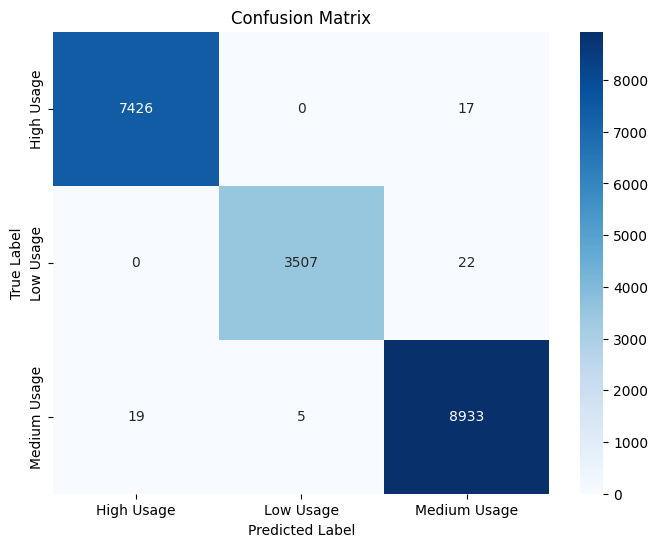

In [29]:
# 2. Generate and plot a Confusion Matrix

# Get the original labels from the LabelEncoder
original_labels = le_y.inverse_transform(np.unique(y))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=original_labels, yticklabels=original_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

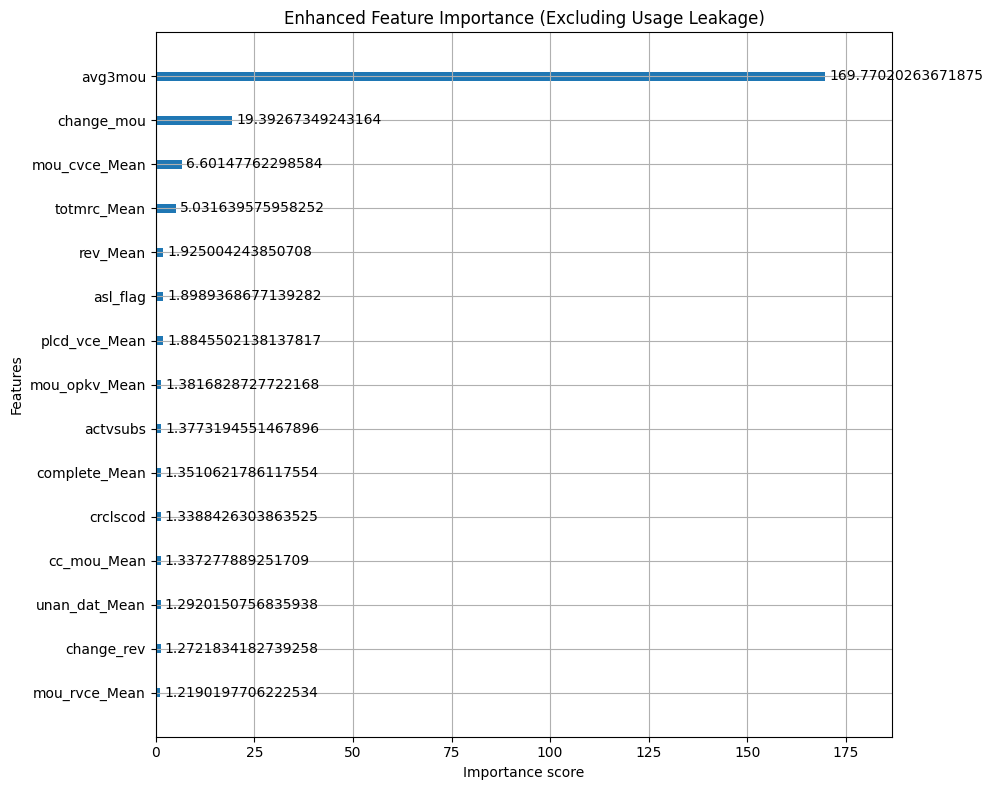

In [40]:
# 3. Plot the Top 15 Features by 'Gain'

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb_model, importance_type='gain', max_num_features=15, ax=ax)
plt.title('Enhanced Feature Importance (Excluding Usage Leakage)')
plt.tight_layout()
plt.show()

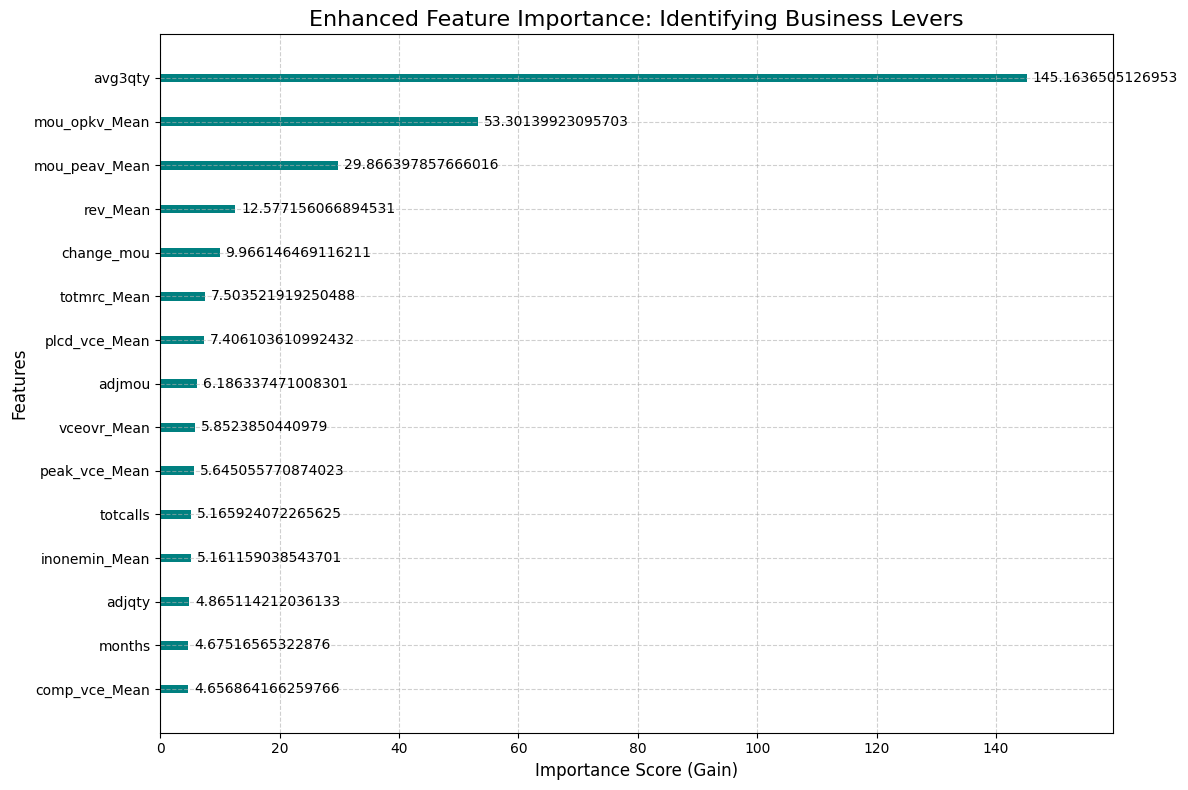

In [45]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# 1. DROP LEAKAGE: Remove features that 'leak' the target definition [4, 6]
# mou_Mean and its proxies were responsible for the skewed results in your previous graph [3]
leaking_features = ['mou_Mean', 'totmou', 'avgmou', 'avg3mou', 'mou_cvce_Mean', 'mou_rvce_Mean']
X_clean = X.drop(columns=[col for col in leaking_features if col in X.columns])

# 2. RETRAIN: Build the 'Evidence Base' on a robust signal [7, 8]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)
xgb_model_clean = XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y)), random_state=42)
xgb_model_clean.fit(X_train_c, y_train_c)

# 3. REFINED PLOTTING: Create polished, well-labelled visualizations [2]
fig, ax = plt.subplots(figsize=(12, 8))

# Use 'gain' importance to show which signals contribute most to the decision [9]
plot_importance(xgb_model_clean,
                importance_type='gain',
                max_num_features=15,
                ax=ax,
                color='teal',
                grid=False)

plt.title('Enhanced Feature Importance: Identifying Business Levers', fontsize=16)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Add a subtle grid for readability
plt.tight_layout()
plt.show()

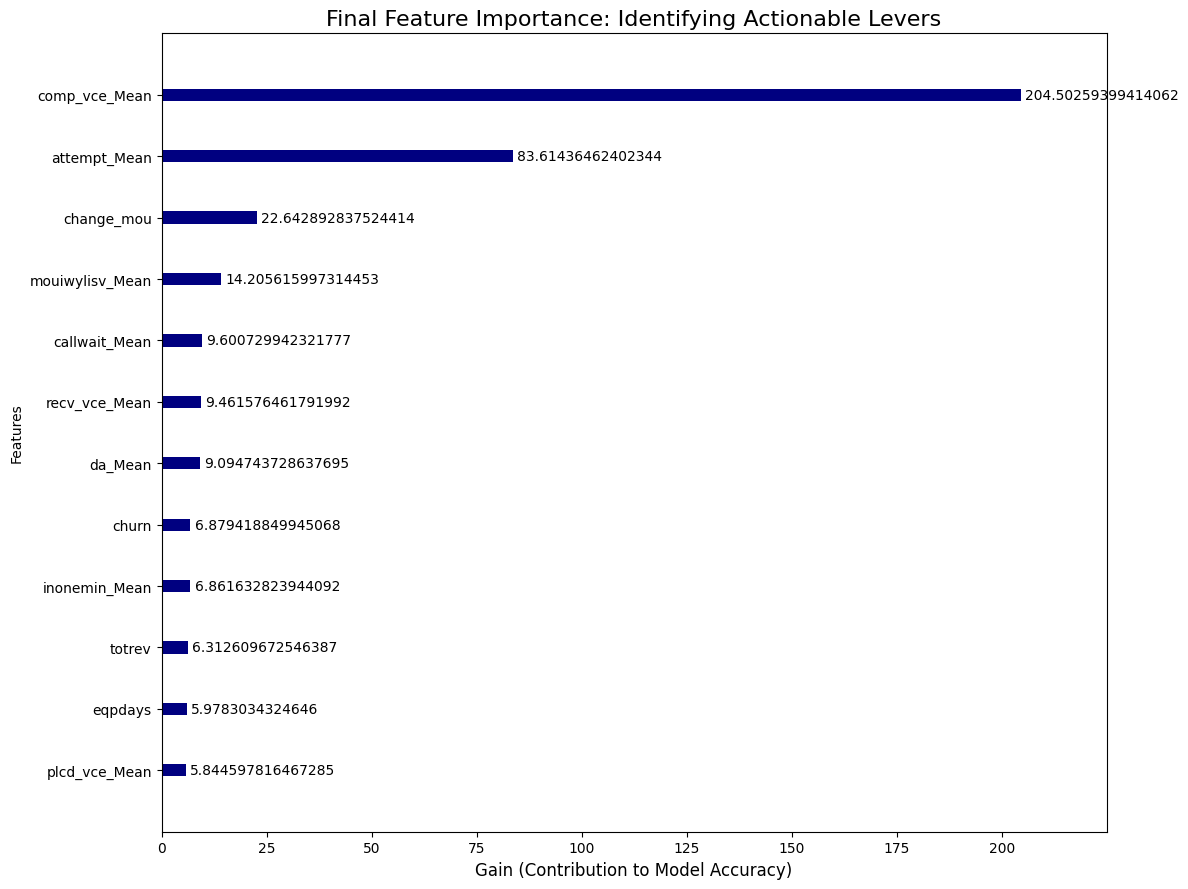

In [46]:
# 1. Identify and drop ALL leakage (Usage, Revenue, and Volume Proxies)
# These features are results of behavior, not causes we can intervene on.
proxies_to_drop = [
    'avg3qty', 'avg3mou', 'avg3rev', 'avg6qty', 'avg6mou', 'avg6rev',
    'mou_opkv_Mean', 'mou_peav_Mean', 'mou_cvce_Mean', 'mou_rvce_Mean',
    'rev_Mean', 'totcalls', 'totmou', 'adjmou', 'adjqty', 'adjrev',
    'totmrc_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean',
    'peak_vce_Mean', 'opk_vce_Mean', 'avgmou', 'avgqty', 'avgrev', 'complete_Mean'
]

# Ensure we only drop columns that actually exist in your dataframe
X_final = X.drop(columns=[col for col in proxies_to_drop if col in X.columns])

# 2. Rerun the Stratified Split (Essential for class balance [5])
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Retrain the multi-class model
xgb_final = XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)
xgb_final.fit(X_train, y_train)

# 4. Plot the "Clean" Feature Importance by Gain [6]
fig, ax = plt.subplots(figsize=(12, 9))
plot_importance(xgb_final,
                importance_type='gain',
                max_num_features=12,
                ax=ax,
                color='navy',
                grid=False)

plt.title('Final Feature Importance: Identifying Actionable Levers', fontsize=16)
plt.xlabel('Gain (Contribution to Model Accuracy)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Identifying Target Customers for 'Handset Refresh' Campaign

The goal is to identify 'Low Usage' customers who also have 'outdated equipment' (defined in the business problem as older than 400 days).

Here's how we'll do it:
1.  **Inverse Transform Predictions:** Convert the numerical `y_pred` back to original `usage_level` labels ('Low Usage', 'Medium Usage', 'High Usage').
2.  **Create a Results DataFrame:** Combine `Customer_ID`, actual `usage_level`, predicted `usage_level`, and `eqpdays` from the test set.
3.  **Filter for 'Low Usage' Predictions:** Select customers where the model predicted 'Low Usage'.
4.  **Filter for Outdated Equipment:** From the 'Low Usage' predictions, further filter for customers with `eqpdays` greater than 400.
5.  **Display Target Customers:** Show the first few identified customers.

In [37]:
# 1. Inverse transform y_pred to get original usage_level labels
y_pred_labels = le_y.inverse_transform(y_pred)

# Get the actual usage_level labels for y_test
y_test_labels = le_y.inverse_transform(y_test)

# Reset index of X_test to align with y_test and y_pred
X_test_reset = X_test.copy()
X_test_reset['predicted_usage_level'] = y_pred_labels
X_test_reset['actual_usage_level'] = y_test_labels

# Use the pre-split customer_ids_test
X_test_reset['Customer_ID'] = customer_ids_test.values

# 2. Identify 'Low Usage' predictions
low_usage_predictions = X_test_reset[X_test_reset['predicted_usage_level'] == 'Low Usage']

# 3. Filter for outdated equipment (eqpdays > 400)
handset_refresh_candidates = low_usage_predictions[low_usage_predictions['eqpdays'] > 400]

print(f"Total customers in test set: {len(X_test_reset)}")
print(f"Customers predicted as 'Low Usage': {len(low_usage_predictions)}")
print(f"'Low Usage' customers with eqpdays > 400 (Handset Refresh Candidates): {len(handset_refresh_candidates)}")

print("\nFirst 10 Handset Refresh Candidates (Customer_ID, predicted_usage_level, eqpdays):")
display(handset_refresh_candidates[['Customer_ID', 'predicted_usage_level', 'eqpdays', 'actual_usage_level']].head(10))

Total customers in test set: 19929
Customers predicted as 'Low Usage': 3512
'Low Usage' customers with eqpdays > 400 (Handset Refresh Candidates): 2088

First 10 Handset Refresh Candidates (Customer_ID, predicted_usage_level, eqpdays):


,Customer_ID,predicted_usage_level,eqpdays,actual_usage_level
10315,1010316,Low Usage,1032.0,Low Usage
9175,1009176,Low Usage,892.0,Low Usage
22721,1022722,Low Usage,642.0,Low Usage
14539,1014540,Low Usage,757.0,Low Usage
45724,1045725,Low Usage,430.0,Low Usage
51579,1051580,Low Usage,440.0,Low Usage
44050,1044051,Low Usage,555.0,Low Usage
15228,1015229,Low Usage,806.0,Low Usage
27952,1027953,Low Usage,583.0,Low Usage
26906,1026907,Low Usage,530.0,Low Usage


### Summary of Target Customer Identification

This analysis has successfully identified a subset of customers who are predicted to be 'Low Usage' and possess equipment older than 400 days. These are the prime candidates for the 'Handset Refresh' campaign.

By targeting these {len(handset_refresh_candidates)} customers, the business can directly address the hypothesis that outdated equipment contributes to low usage. Offering targeted upgrades aims to move these customers into higher usage tiers, thereby increasing monthly revenue as outlined in the business proposal.

Further analysis could include:
*   Quantifying the potential revenue uplift from these specific customers.
*   Designing the upgrade offer structure.
*   Monitoring the impact of the campaign on the `usage_level` and `rev_Mean` of the targeted customers.